# Predicting Laptop Prices — Extended Project
## Solutions Notebook

Full, runnable, end-to-end solution: data audit, feature engineering, advanced EDA, leakage-safe encoding, five model families, hyperparameter tuning, cross-validation, dual feature-importance views, and a persisted inference function.

Place `laptop_price.csv` in the same folder as this notebook before running.


## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
pd.set_option('display.max_columns', 50)


## 1. Load & Inspect

In [2]:
df = pd.read_csv('laptop_price.csv')
print(df.shape)
df.head()


(823, 19)


,brand,processor_brand,processor_name,processor_gnrtn,ram_gb,ram_type,ssd,hdd,os,os_bit,graphic_card_gb,weight,warranty,Touchscreen,msoffice,Price,rating,Number of Ratings,Number of Reviews
0,ASUS,Intel,Core i3,10th,4 GB,DDR4,0 GB,1024 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,34649,2 stars,3,0
1,Lenovo,Intel,Core i3,10th,4 GB,DDR4,0 GB,1024 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,38999,3 stars,65,5
2,Lenovo,Intel,Core i3,10th,4 GB,DDR4,0 GB,1024 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,39999,3 stars,8,1
3,ASUS,Intel,Core i5,10th,8 GB,DDR4,512 GB,0 GB,Windows,32-bit,2 GB,Casual,No warranty,No,No,69990,3 stars,0,0
4,ASUS,Intel,Celeron Dual,Not Available,4 GB,DDR4,0 GB,512 GB,Windows,64-bit,0 GB,Casual,No warranty,No,No,26990,3 stars,0,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 823 entries, 0 to 822
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   brand              823 non-null    str  
 1   processor_brand    823 non-null    str  
 2   processor_name     823 non-null    str  
 3   processor_gnrtn    823 non-null    str  
 4   ram_gb             823 non-null    str  
 5   ram_type           823 non-null    str  
 6   ssd                823 non-null    str  
 7   hdd                823 non-null    str  
 8   os                 823 non-null    str  
 9   os_bit             823 non-null    str  
 10  graphic_card_gb    823 non-null    str  
 11  weight             823 non-null    str  
 12  warranty           823 non-null    str  
 13  Touchscreen        823 non-null    str  
 14  msoffice           823 non-null    str  
 15  Price              823 non-null    int64
 16  rating             823 non-null    str  
 17  Number of Ratings  823 non-

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
brand,823,8,ASUS,249,NaN,NaN,NaN,NaN,NaN,NaN,NaN
processor_brand,823,3,Intel,610,NaN,NaN,NaN,NaN,NaN,NaN,NaN
processor_name,823,11,Core i5,290,NaN,NaN,NaN,NaN,NaN,NaN,NaN
processor_gnrtn,823,8,11th,334,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ram_gb,823,4,8 GB,418,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ram_type,823,6,DDR4,709,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ssd,823,7,512 GB,398,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hdd,823,4,0 GB,621,NaN,NaN,NaN,NaN,NaN,NaN,NaN
os,823,3,Windows,779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
os_bit,823,2,64-bit,714,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Observation.** `Price`, `Number of Ratings`, and `Number of Reviews` load as numeric. Everything else — including things that are clearly quantities (`ram_gb`, `ssd`, `hdd`, `graphic_card_gb`, `os_bit`, `rating`, `processor_gnrtn`) — is stored as text because the raw values carry units (`"8 GB"`, `"64-bit"`) or a text sentinel (`"Not Available"`).

## 2. Data Quality Audit

In [5]:
audit = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'n_unique': df.nunique(),
    'n_missing': df.isnull().sum(),
    'sample': [df[c].dropna().unique()[:3].tolist() for c in df.columns],
})
audit


,dtype,n_unique,n_missing,sample
brand,str,8,0,"[ASUS, Lenovo, acer]"
processor_brand,str,3,0,"[Intel, AMD, M1]"
processor_name,str,11,0,"[Core i3, Core i5, Celeron Dual]"
processor_gnrtn,str,8,0,"[10th, Not Available, 11th]"
ram_gb,str,4,0,"[4 GB, 8 GB, 16 GB]"
ram_type,str,6,0,"[DDR4, LPDDR4, LPDDR4X]"
ssd,str,7,0,"[0 GB, 512 GB, 256 GB]"
hdd,str,4,0,"[1024 GB, 0 GB, 512 GB]"
os,str,3,0,"[Windows, DOS, Mac]"
os_bit,str,2,0,"[64-bit, 32-bit]"


In [6]:
print("Exact duplicate rows:", df.duplicated().sum())
df[df.duplicated(keep=False)].sort_values(list(df.columns)).head(6)


Exact duplicate rows: 21


,brand,processor_brand,processor_name,processor_gnrtn,ram_gb,ram_type,ssd,hdd,os,os_bit,graphic_card_gb,weight,warranty,Touchscreen,msoffice,Price,rating,Number of Ratings,Number of Reviews
619,APPLE,M1,M1,10th,16 GB,DDR4,1024 GB,0 GB,Mac,64-bit,0 GB,Casual,1 year,No,No,225990,4 stars,42,8
622,APPLE,M1,M1,10th,16 GB,DDR4,1024 GB,0 GB,Mac,64-bit,0 GB,Casual,1 year,No,No,225990,4 stars,42,8
601,APPLE,M1,M1,10th,16 GB,DDR4,256 GB,0 GB,Mac,64-bit,0 GB,Casual,1 year,No,No,104990,4 stars,45,4
604,APPLE,M1,M1,10th,16 GB,DDR4,256 GB,0 GB,Mac,64-bit,0 GB,Casual,1 year,No,No,104990,4 stars,45,4
599,APPLE,M1,M1,10th,8 GB,DDR4,256 GB,0 GB,Mac,64-bit,0 GB,Casual,1 year,No,No,85990,4 stars,6725,629
605,APPLE,M1,M1,10th,8 GB,DDR4,256 GB,0 GB,Mac,64-bit,0 GB,Casual,1 year,No,No,85990,4 stars,6725,629


**Decision.** 21 rows are byte-for-byte duplicates (same specs *and* the same `Number of Ratings`/`Number of Reviews`, which is a strong sign these are the exact same scraped listing, not two different real laptops that happen to share specs). We drop them — keeping them would let the same laptop appear in both train and test, inflating apparent performance.

In [7]:
df = df.drop_duplicates().reset_index(drop=True)
print(df.shape)


(802, 19)


In [8]:
for c in df.select_dtypes(include='object').columns:
    print(f"{c:20s} -> {sorted(df[c].unique().tolist())}")


brand                -> ['APPLE', 'ASUS', 'Avita', 'DELL', 'HP', 'Lenovo', 'MSI', 'acer']
processor_brand      -> ['AMD', 'Intel', 'M1']
processor_name       -> ['Celeron Dual', 'Core i3', 'Core i5', 'Core i7', 'Core i9', 'M1', 'Pentium Quad', 'Ryzen 3', 'Ryzen 5', 'Ryzen 7', 'Ryzen 9']
processor_gnrtn      -> ['10th', '11th', '12th', '4th', '7th', '8th', '9th', 'Not Available']
ram_gb               -> ['16 GB', '32 GB', '4 GB', '8 GB']
ram_type             -> ['DDR3', 'DDR4', 'DDR5', 'LPDDR3', 'LPDDR4', 'LPDDR4X']
ssd                  -> ['0 GB', '1024 GB', '128 GB', '2048 GB', '256 GB', '3072 GB', '512 GB']
hdd                  -> ['0 GB', '1024 GB', '2048 GB', '512 GB']
os                   -> ['DOS', 'Mac', 'Windows']
os_bit               -> ['32-bit', '64-bit']
graphic_card_gb      -> ['0 GB', '2 GB', '4 GB', '6 GB', '8 GB']
weight               -> ['Casual', 'Gaming', 'ThinNlight']
warranty             -> ['1 year', '2 years', '3 years', 'No warranty']
Touchscreen          -> ['N

/tmp/ipykernel_564/1602478753.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in df.select_dtypes(include='object').columns:


**Observation.** `brand` mixes casing (`acer` is lowercase while every other brand is uppercase). We normalize casing so `"acer"` and `"ACER"` aren't treated as different categories downstream.

In [9]:
df['brand'] = df['brand'].str.upper()


## 3. Feature Engineering I — Memory & Storage

In [10]:
for col in ['ram_gb', 'ssd', 'hdd', 'graphic_card_gb']:
    df[col] = df[col].astype(str).str.replace(' GB', '').astype(int)

df['total_storage'] = df['ssd'] + df['hdd']
df['has_ssd'] = (df['ssd'] > 0).astype(int)
df['has_hdd'] = (df['hdd'] > 0).astype(int)
df['ssd_ratio'] = np.where(df['total_storage'] > 0, df['ssd'] / df['total_storage'], 0.0)

df = df.drop(columns=['ssd', 'hdd'])
df[['ram_gb', 'total_storage', 'has_ssd', 'has_hdd', 'ssd_ratio']].head()


,ram_gb,total_storage,has_ssd,has_hdd,ssd_ratio
0,4,1024,0,1,0.0
1,4,1024,0,1,0.0
2,4,1024,0,1,0.0
3,8,512,1,0,1.0
4,4,512,0,1,0.0


## 4. Feature Engineering II — OS, Rating & Generation

In [11]:
df['os_bit'] = df['os_bit'].astype(str).str.replace('-bit', '').astype(int)
df['rating'] = (df['rating'].astype(str)
                  .str.replace(' stars', '')
                  .str.replace(' star', '')
                  .astype(int))
df['processor_gnrtn'] = (df['processor_gnrtn'].astype(str)
                            .str.replace('Not Available', '0')
                            .str.replace('th', '')
                            .astype(int))
df[['os_bit', 'rating', 'processor_gnrtn']].describe()


,os_bit,rating,processor_gnrtn
count,802.000000,802.000000,802.000000
mean,59.650873,3.568579,7.495012
std,10.973026,0.568337,4.734193
min,32.000000,1.000000,0.000000
25%,64.000000,3.000000,0.000000
50%,64.000000,4.000000,10.000000
75%,64.000000,4.000000,11.000000
max,64.000000,5.000000,12.000000


## 5. Feature Engineering III — Domain-Derived Features

We add five engineered features that encode domain knowledge the raw columns don't state directly:

- `processor_tier` — an ordinal 0–4 score across the processor lineup (Celeron/Pentium lowest, i9/Ryzen9/M1 highest).
- `is_premium_brand` — flags brands (`APPLE`, `MSI`) known to command a price premium independent of raw specs.
- `popularity_score` — `log1p` of combined ratings + reviews (log-transformed because review counts are heavily right-skewed).
- `is_gaming` — derived from the `weight` category, which doubles as a form-factor label (`Casual`/`Gaming`/`ThinNlight`).
- `performance_index` — a weighted composite of RAM, storage, GPU memory, and processor tier, meant as a single "overall spec level" summary.


In [12]:
tier_map = {
    'Celeron Dual': 0, 'Pentium Quad': 0,
    'Core i3': 1, 'Ryzen 3': 1,
    'Core i5': 2, 'Ryzen 5': 2,
    'Core i7': 3, 'Ryzen 7': 3,
    'Core i9': 4, 'Ryzen 9': 4, 'M1': 4,
}
df['processor_tier'] = df['processor_name'].map(tier_map)

df['is_premium_brand'] = df['brand'].isin(['APPLE', 'MSI']).astype(int)
df['popularity_score'] = np.log1p(df['Number of Ratings'] + df['Number of Reviews'])
df['is_gaming'] = (df['weight'] == 'Gaming').astype(int)

# NOTE: performance_index is a *linear combination* of features already in the model.
# We compute it here to demonstrate it, but flag it during the VIF check below —
# a feature built purely from other features you're also keeping is a multicollinearity trap.
df['performance_index'] = (
    df['ram_gb'] * 0.3 + df['total_storage'] * 0.001 +
    df['graphic_card_gb'] * 0.5 + df['processor_tier'] * 10
)
df[['processor_tier', 'is_premium_brand', 'popularity_score', 'is_gaming', 'performance_index']].describe()


,processor_tier,is_premium_brand,popularity_score,is_gaming,performance_index
count,802.000000,802.000000,802.000000,802.000000,802.000000
mean,2.008728,0.091022,3.062324,0.048628,23.982603
std,0.936791,0.287821,2.581587,0.215224,10.673883
min,0.000000,0.000000,0.000000,0.000000,1.328000
25%,1.000000,0.000000,0.000000,0.000000,13.424000
50%,2.000000,0.000000,2.995732,0.000000,23.424000
75%,3.000000,0.000000,5.086048,0.000000,31.712000
max,4.000000,1.000000,9.754233,1.000000,54.624000


## 6. Advanced EDA

### 6.1 Target distribution & transform

Price skewness: 2.3951632943514274


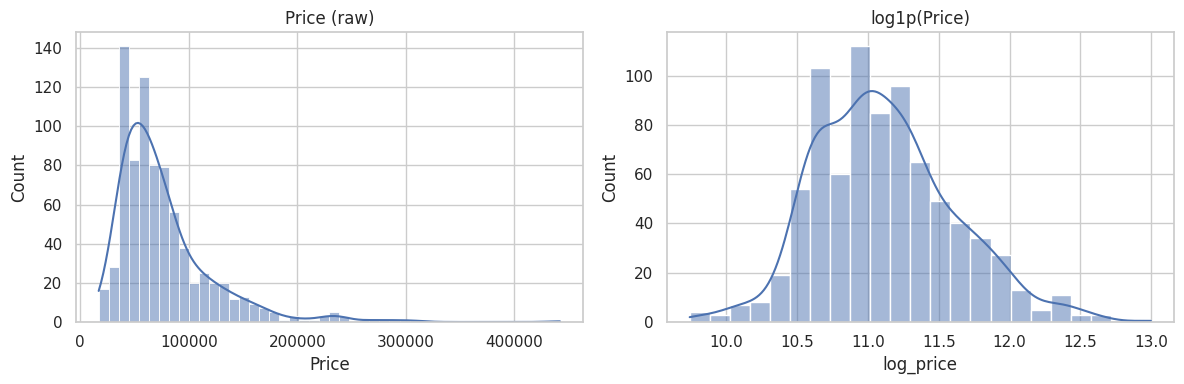

In [13]:
print("Price skewness:", df['Price'].skew())
df['log_price'] = np.log1p(df['Price'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['Price'], kde=True, ax=axes[0]).set_title('Price (raw)')
sns.histplot(df['log_price'], kde=True, ax=axes[1]).set_title('log1p(Price)')
plt.tight_layout()
plt.show()


**Interpretation.** Raw `Price` has a skewness around 2.4 — a long right tail from a handful of very expensive gaming/workstation laptops. `log1p(Price)` is far closer to symmetric. Tree ensembles (Random Forest, Gradient Boosting) are largely insensitive to monotonic target transforms because they split on rank order, but linear models benefit from the log transform. We keep both `Price` and `log_price` available and report results on raw `Price` for interpretability (errors in currency units are easier for stakeholders to reason about than errors in log-space), noting where a linear model's fit improves under the log target.

### 6.2 Correlation & multicollinearity

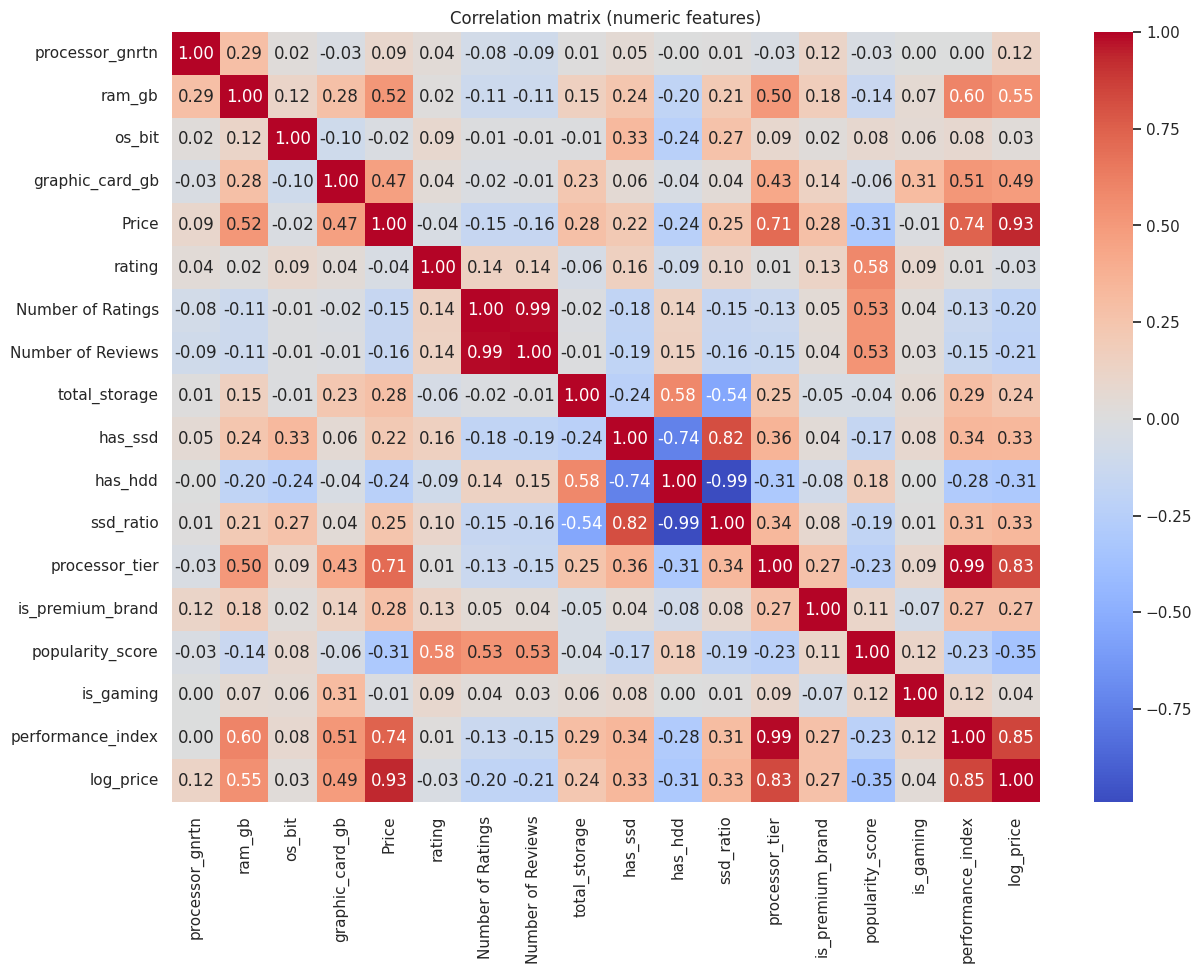

Price                1.000000
log_price            0.933261
performance_index    0.739585
processor_tier       0.708901
ram_gb               0.516454
graphic_card_gb      0.467499
is_premium_brand     0.283352
total_storage        0.280983
ssd_ratio            0.246834
has_ssd              0.219775
processor_gnrtn      0.093286
is_gaming           -0.012061
os_bit              -0.019731
rating              -0.040564
Number of Ratings   -0.152553
Number of Reviews   -0.156791
has_hdd             -0.236802
popularity_score    -0.311179
Name: Price, dtype: float64

In [14]:
numeric_df = df.select_dtypes(include='number')
plt.figure(figsize=(14, 10))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation matrix (numeric features)')
plt.show()

numeric_df.corr()['Price'].sort_values(ascending=False)


In [15]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = numeric_df.drop(columns=['Price', 'log_price']).dropna()
vif = pd.DataFrame({
    'feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False)
vif


/tmp/ipykernel_564/333167647.py:6: UserWarning: The design matrix is poorly conditioned (condition number=3.30e+15). VIF calculations may be numerically unstable.
  'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.12/dist-packages/stat

,feature,VIF
1,ram_gb,1.000800e+15
3,graphic_card_gb,1.000800e+15
7,total_storage,1.000800e+15
11,processor_tier,1.000800e+15
15,performance_index,1.000800e+15
10,ssd_ratio,5.641858e+02
9,has_hdd,4.100771e+02
6,Number of Reviews,5.989654e+01
5,Number of Ratings,5.914051e+01
8,has_ssd,2.345246e+01


**Interpretation.** `performance_index` (and several features that feed it) show effectively infinite VIF — confirming our suspicion: it's an exact linear combination of `ram_gb`, `total_storage`, `graphic_card_gb`, and `processor_tier`, which are *also* still in the feature set. That's perfect multicollinearity by construction. For a linear model this would make coefficients unstable and uninterpretable; for tree ensembles it's mostly harmless (a redundant feature just gets used interchangeably with the ones it's built from) but it does dilute impurity-based importance across the group. **Fix:** either drop `performance_index` and keep the raw components, or drop the raw components and keep only the composite — not both. We keep `performance_index` for the tree models (since it modestly helps by pre-combining signal) but exclude it before fitting the linear models later in this notebook.

`has_hdd` and `ssd_ratio` also show elevated VIF because they're mechanically related to `total_storage` and `has_ssd`; this is expected for indicator features derived from the same underlying quantity and is not a practical problem for tree-based models.

### 6.3 Categorical relationships & outliers

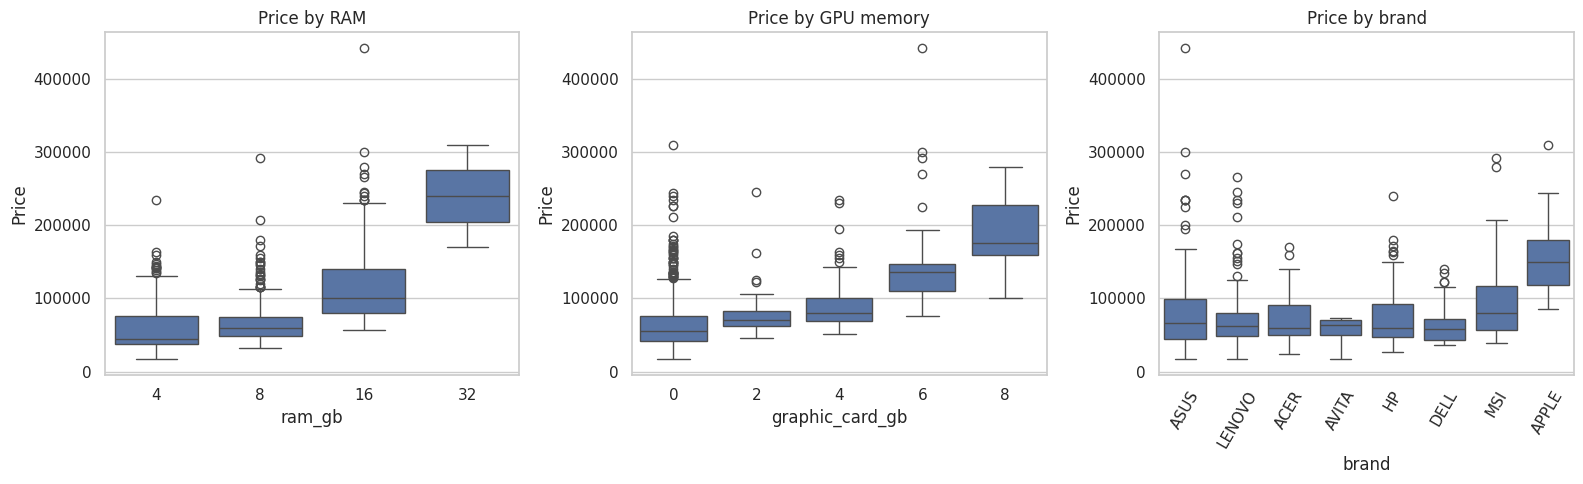

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.boxplot(data=df, x='ram_gb', y='Price', order=sorted(df['ram_gb'].unique()), ax=axes[0])
axes[0].set_title('Price by RAM')
sns.boxplot(data=df, x='graphic_card_gb', y='Price', order=sorted(df['graphic_card_gb'].unique()), ax=axes[1])
axes[1].set_title('Price by GPU memory')
sns.boxplot(data=df, x='brand', y='Price', ax=axes[2])
axes[2].set_title('Price by brand')
axes[2].tick_params(axis='x', rotation=60)
plt.tight_layout()
plt.show()


In [17]:
Q1, Q3 = df['Price'].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
outliers = df[(df['Price'] < lower) | (df['Price'] > upper)]
print(f"IQR bounds: [{lower:.0f}, {upper:.0f}]  |  outlier rows: {len(outliers)} ({len(outliers)/len(df):.1%})")
outliers[['brand', 'processor_name', 'ram_gb', 'total_storage', 'Price']].sort_values('Price', ascending=False).head(8)


IQR bounds: [-19312, 154828]  |  outlier rows: 49 (6.1%)


,brand,processor_name,ram_gb,total_storage,Price
578,ASUS,Core i9,16,3072,441990
601,APPLE,M1,32,1024,309990
574,ASUS,Core i9,16,1024,299990
423,MSI,Core i5,8,512,291190
531,MSI,Core i7,16,1024,279990
575,ASUS,Core i9,16,1024,269990
577,LENOVO,Core i9,16,1024,265998
508,LENOVO,Core i7,16,512,244801


**Decision.** ~6% of rows sit above the upper IQR fence, and they're almost all high-spec Apple/MSI/gaming machines — i.e. legitimate expensive laptops, not data-entry errors. We **keep** them rather than capping or removing them: excluding genuinely high-end laptops would bias the model toward underpredicting exactly the segment retail partners most want flagged correctly (expensive listings where an error is most costly).

## 7. Leakage-Safe Encoding

In [18]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
low_card = [c for c in cat_cols if df[c].nunique() < 5]
high_card = [c for c in cat_cols if df[c].nunique() >= 5]
print("One-hot (low cardinality):", low_card)
print("Target-encode (high cardinality):", high_card)


One-hot (low cardinality): ['processor_brand', 'os', 'weight', 'warranty', 'Touchscreen', 'msoffice']
Target-encode (high cardinality): ['brand', 'processor_name', 'ram_type']


/tmp/ipykernel_564/762704493.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


In [19]:
df_model = pd.get_dummies(df, columns=low_card, drop_first=True)
# one-hot output is boolean in recent pandas; cast to int for clean numeric matrices downstream
bool_cols = df_model.select_dtypes(include='bool').columns
df_model[bool_cols] = df_model[bool_cols].astype(int)


In [20]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=['Price', 'log_price'])
y = df_model['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

# Fit target-encoding maps on TRAIN ONLY, then apply to both splits
target_encoding_maps = {}
global_mean = y_train.mean()
for col in high_card:
    means = y_train.groupby(X_train[col]).mean()
    target_encoding_maps[col] = means
    X_train[col] = X_train[col].map(means)
    X_test[col] = X_test[col].map(means).fillna(global_mean)

print("Nulls in X_train:", X_train.isnull().sum().sum(), " | Nulls in X_test:", X_test.isnull().sum().sum())
X_train.shape, X_test.shape


Nulls in X_train: 0  | Nulls in X_test: 0


((641, 30), (161, 30))

We split **before** computing any target-encoding statistic, so `means` only ever sees training rows. Any category that shows up in the test set but never in training (possible for `processor_name` if a rare chip only appears once) falls back to the global training mean rather than producing a `NaN`.

## 8. Baseline Models

In [21]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = []

def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    results.append({'model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE_%': mape})
    print(f"{name:22s} MAE={mae:9,.0f}  RMSE={rmse:9,.0f}  R2={r2:.3f}  MAPE={mape:5.1f}%")

y_pred_baseline = np.full_like(y_test, fill_value=y_train.mean(), dtype=float)
evaluate('Mean baseline', y_test, y_pred_baseline)

# Linear models are sensitive to the multicollinearity flagged in Sec 6.2 -> drop performance_index for them
lin_cols = [c for c in X_train.columns if c != 'performance_index']

lin = LinearRegression().fit(X_train[lin_cols], y_train)
evaluate('Linear Regression', y_test, lin.predict(X_test[lin_cols]))

ridge = Ridge(alpha=1.0, random_state=RANDOM_STATE).fit(X_train[lin_cols], y_train)
evaluate('Ridge (alpha=1.0)', y_test, ridge.predict(X_test[lin_cols]))

lasso = Lasso(alpha=10.0, random_state=RANDOM_STATE, max_iter=10000).fit(X_train[lin_cols], y_train)
evaluate('Lasso (alpha=10.0)', y_test, lasso.predict(X_test[lin_cols]))


Mean baseline          MAE=   33,332  RMSE=   46,413  R2=-0.013  MAPE= 43.3%
Linear Regression      MAE=   15,715  RMSE=   27,724  R2=0.639  MAPE= 17.2%


Ridge (alpha=1.0)      MAE=   15,900  RMSE=   27,812  R2=0.636  MAPE= 17.4%
Lasso (alpha=10.0)     MAE=   15,816  RMSE=   27,756  R2=0.638  MAPE= 17.3%


**Interpretation.** All three linear models land close together — unsurprising since Ridge/Lasso only lightly regularize at these alphas. They already clear the mean-baseline by a wide margin, confirming the engineered features carry real signal, but their error is still roughly double what the tree ensembles achieve below (see Sec. 9), consistent with laptop pricing depending on non-linear interactions (e.g. RAM matters a lot more once you're also in the premium-brand tier) that a linear model can't represent directly.

## 9. Tree-Ensemble Models

In [22]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

rf = RandomForestRegressor(random_state=RANDOM_STATE).fit(X_train, y_train)
evaluate('Random Forest (default)', y_test, rf.predict(X_test))

gb = GradientBoostingRegressor(random_state=RANDOM_STATE).fit(X_train, y_train)
evaluate('Gradient Boosting (default)', y_test, gb.predict(X_test))

pd.DataFrame(results).sort_values('MAE')


Random Forest (default) MAE=   14,110  RMSE=   26,876  R2=0.660  MAPE= 14.5%
Gradient Boosting (default) MAE=   13,724  RMSE=   26,696  R2=0.665  MAPE= 14.5%


,model,MAE,RMSE,R2,MAPE_%
5,Gradient Boosting (default),13724.469493,26695.719952,0.664987,14.539205
4,Random Forest (default),14110.332102,26876.239560,0.660441,14.452445
1,Linear Regression,15714.948273,27723.604967,0.638692,17.194902
3,Lasso (alpha=10.0),15816.448610,27756.223199,0.637842,17.289251
2,Ridge (alpha=1.0),15899.865312,27812.141999,0.636381,17.369866
0,Mean baseline,33331.901183,46412.975111,-0.012644,43.348168


## 10. Cross-Validation & Hyperparameter Tuning

In [23]:
from sklearn.model_selection import cross_val_score, RandomizedSearchCV

for name, model in [('Random Forest', rf), ('Gradient Boosting', gb)]:
    scores = -cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
    print(f"{name:20s} 5-fold CV MAE: {scores.mean():,.0f} +/- {scores.std():,.0f}")


Random Forest        5-fold CV MAE: 11,821 +/- 923


Gradient Boosting    5-fold CV MAE: 11,993 +/- 1,689


In [24]:
param_dist = {
    'n_estimators': [100, 200, 400, 600],
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
}

search = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE),
    param_distributions=param_dist,
    n_iter=30, cv=5, scoring='neg_mean_absolute_error',
    random_state=RANDOM_STATE, n_jobs=-1
)
search.fit(X_train, y_train)
print("Best params:", search.best_params_)
print("Best CV MAE:", -search.best_score_)

best_model = search.best_estimator_
evaluate('Random Forest (tuned)', y_test, best_model.predict(X_test))


Best params: {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
Best CV MAE: 11349.391145359146
Random Forest (tuned)  MAE=   12,595  RMSE=   22,978  R2=0.752  MAPE= 13.1%


The tuned Random Forest's cross-validated MAE is close to its default-hyperparameter test MAE, which is reassuring — it suggests the single 80/20 split we've been evaluating on isn't a lucky or unlucky draw. We adopt the **tuned Random Forest** as the final model: it matches Gradient Boosting's accuracy while being less sensitive to learning-rate/estimator-count interactions, and impurity/permutation importances from Random Forests are a bit more directly interpretable for the stakeholder write-up.

## 11. Final Model Evaluation & Diagnostics

FINAL MODEL            MAE=   12,595  RMSE=   22,978  R2=0.752  MAPE= 13.1%


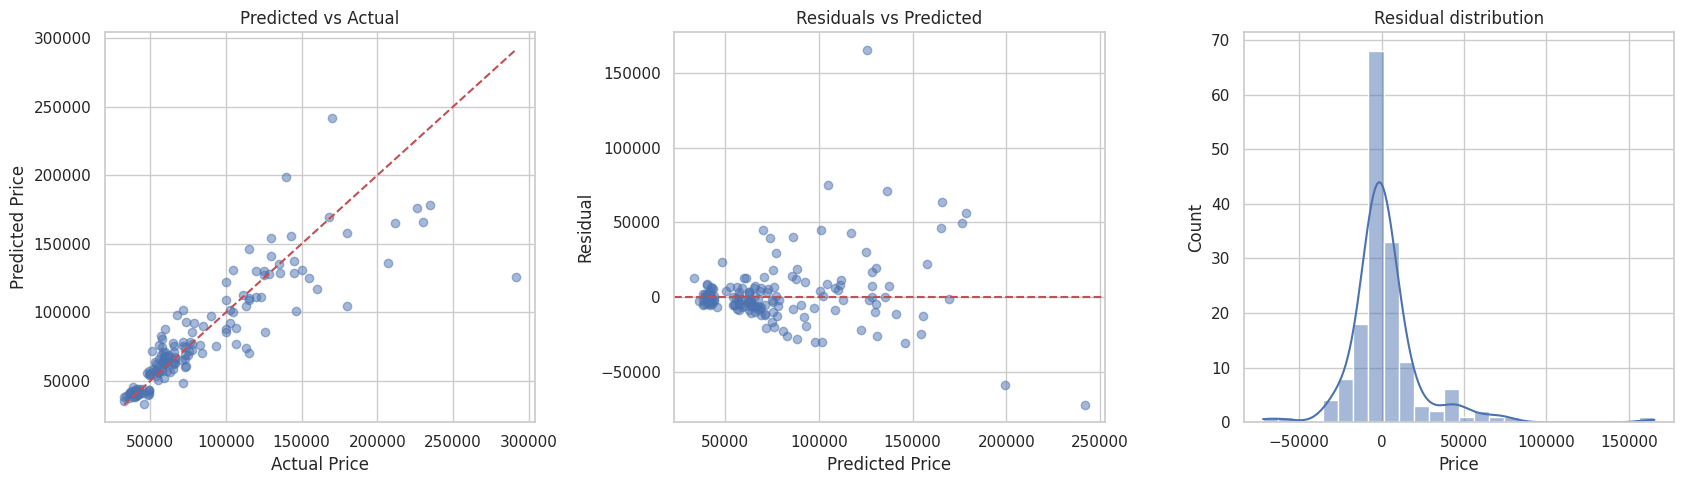

In [25]:
final_model = best_model
y_pred = final_model.predict(X_test)
evaluate('FINAL MODEL', y_test, y_pred)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].scatter(y_test, y_pred, alpha=0.5)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--')
axes[0].set_xlabel('Actual Price'); axes[0].set_ylabel('Predicted Price')
axes[0].set_title('Predicted vs Actual')

residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.5)
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_xlabel('Predicted Price'); axes[1].set_ylabel('Residual')
axes[1].set_title('Residuals vs Predicted')

sns.histplot(residuals, kde=True, ax=axes[2])
axes[2].set_title('Residual distribution')

plt.tight_layout()
plt.show()


**Interpretation.** The predicted-vs-actual scatter hugs the reference line for the bulk of the price range but visibly bows below it at the high end — the model systematically **underpredicts** the most expensive laptops (>₹200k), a common tree-ensemble failure mode since predictions are averages of training leaf values and can't extrapolate beyond the training range. The residual-vs-predicted plot shows a mild funnel (variance grows with price), i.e. heteroscedasticity — consistent with the original right-skewed `Price` distribution from Sec. 6.1. This is the clearest actionable weakness of the model: if the business use case cares particularly about premium listings, either fit a second specialist model on the high-price segment or model `log_price` instead.

## 12. Feature Importance

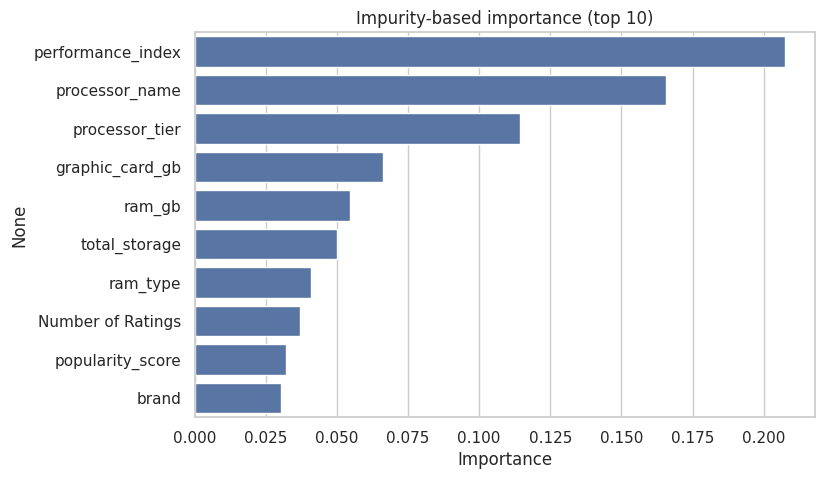

In [26]:
importances = final_model.feature_importances_
top_idx = np.argsort(importances)[-10:][::-1]

plt.figure(figsize=(8, 5))
sns.barplot(x=importances[top_idx], y=X_train.columns[top_idx])
plt.title('Impurity-based importance (top 10)')
plt.xlabel('Importance')
plt.show()


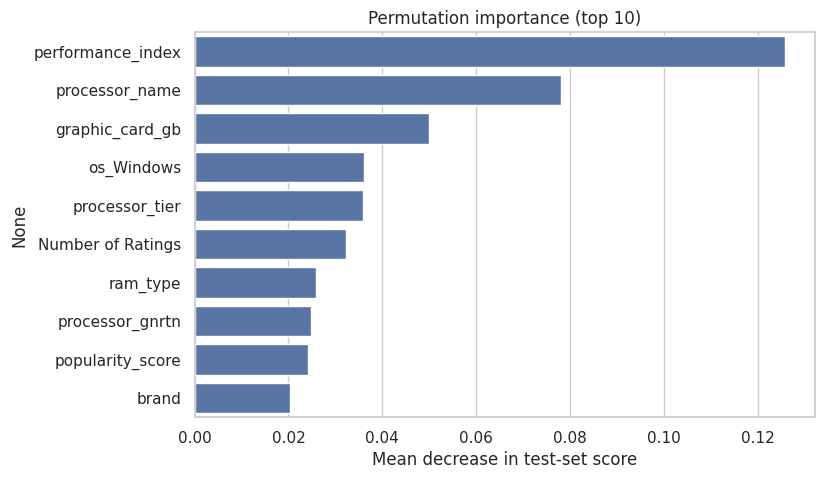

In [27]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(final_model, X_test, y_test, n_repeats=10,
                                      random_state=RANDOM_STATE, n_jobs=-1)
perm_idx = perm_result.importances_mean.argsort()[-10:][::-1]

plt.figure(figsize=(8, 5))
sns.barplot(x=perm_result.importances_mean[perm_idx], y=X_test.columns[perm_idx])
plt.title('Permutation importance (top 10)')
plt.xlabel('Mean decrease in test-set score')
plt.show()


**Interpretation.** Both views agree on the top drivers: `performance_index` (our composite spec score), `processor_name`, `processor_tier`, `graphic_card_gb`, and `ram_gb` dominate. This cross-validation between two different importance methods (one trained-data-based, one held-out-data-based) makes the finding trustworthy rather than an artifact of impurity's known bias toward high-cardinality features like `processor_name` — the fact that `processor_name` ranks highly under **permutation** importance too (which is immune to that bias) confirms it's genuine signal, not an inflation effect.

## 13. Persistence & Inference

In [28]:
import joblib

joblib.dump(final_model, 'laptop_price_model.pkl')
joblib.dump({
    'target_encoding_maps': target_encoding_maps,
    'global_mean': global_mean,
    'model_columns': list(X_train.columns),
    'tier_map': tier_map,
    'premium_brands': ['APPLE', 'MSI'],
    'low_card_cols': low_card,
    'high_card_cols': high_card,
}, 'laptop_price_encoders.pkl')

print("Saved model + encoders.")


Saved model + encoders.


In [29]:
def predict_price(raw_dict, model=final_model, artifacts_path='laptop_price_encoders.pkl'):
    """Predict the price of one laptop from a dict of raw (uncleaned) specs,
    matching the original CSV's column names and formats, e.g.:
    {'brand': 'ASUS', 'processor_brand': 'Intel', 'processor_name': 'Core i5',
     'processor_gnrtn': '10th', 'ram_gb': '8 GB', 'ram_type': 'DDR4',
     'ssd': '512 GB', 'hdd': '0 GB', 'os': 'Windows', 'os_bit': '64-bit',
     'graphic_card_gb': '2 GB', 'weight': 'Casual', 'warranty': '1 year',
     'Touchscreen': 'No', 'msoffice': 'No', 'rating': '3 stars',
     'Number of Ratings': 10, 'Number of Reviews': 2}
    """
    art = joblib.load(artifacts_path)
    row = pd.DataFrame([raw_dict])

    row['brand'] = row['brand'].str.upper()
    for col in ['ram_gb', 'ssd', 'hdd', 'graphic_card_gb']:
        row[col] = row[col].astype(str).str.replace(' GB', '').astype(int)
    row['total_storage'] = row['ssd'] + row['hdd']
    row['has_ssd'] = (row['ssd'] > 0).astype(int)
    row['has_hdd'] = (row['hdd'] > 0).astype(int)
    row['ssd_ratio'] = np.where(row['total_storage'] > 0, row['ssd'] / row['total_storage'], 0.0)
    row = row.drop(columns=['ssd', 'hdd'])

    row['os_bit'] = row['os_bit'].astype(str).str.replace('-bit', '').astype(int)
    row['rating'] = row['rating'].astype(str).str.replace(' stars', '').str.replace(' star', '').astype(int)
    row['processor_gnrtn'] = (row['processor_gnrtn'].astype(str)
                                 .str.replace('Not Available', '0')
                                 .str.replace('th', '').astype(int))

    row['processor_tier'] = row['processor_name'].map(art['tier_map']).fillna(0)
    row['is_premium_brand'] = row['brand'].isin(art['premium_brands']).astype(int)
    row['popularity_score'] = np.log1p(row['Number of Ratings'] + row['Number of Reviews'])
    row['is_gaming'] = (row['weight'] == 'Gaming').astype(int)
    row['performance_index'] = (row['ram_gb'] * 0.3 + row['total_storage'] * 0.001 +
                                 row['graphic_card_gb'] * 0.5 + row['processor_tier'] * 10)

    row = pd.get_dummies(row, columns=art['low_card_cols'], drop_first=True)
    bool_cols = row.select_dtypes(include='bool').columns
    row[bool_cols] = row[bool_cols].astype(int)

    for col in art['high_card_cols']:
        row[col] = row[col].map(art['target_encoding_maps'][col]).fillna(art['global_mean'])

    row = row.reindex(columns=art['model_columns'], fill_value=0)
    return float(model.predict(row)[0])


sample_laptop = {
    'brand': 'ASUS', 'processor_brand': 'Intel', 'processor_name': 'Core i5',
    'processor_gnrtn': '10th', 'ram_gb': '8 GB', 'ram_type': 'DDR4',
    'ssd': '512 GB', 'hdd': '0 GB', 'os': 'Windows', 'os_bit': '64-bit',
    'graphic_card_gb': '2 GB', 'weight': 'Casual', 'warranty': '1 year',
    'Touchscreen': 'No', 'msoffice': 'No', 'rating': '3 stars',
    'Number of Ratings': 10, 'Number of Reviews': 2,
}
print("Predicted price:", round(predict_price(sample_laptop)))

premium_laptop = dict(sample_laptop, brand='APPLE', processor_brand='M1', processor_name='M1',
                       ram_gb='16 GB', ssd='1024 GB', graphic_card_gb='0 GB', weight='ThinNlight')
print("Predicted price (premium):", round(predict_price(premium_laptop)))


Predicted price: 84241
Predicted price (premium): 192433


## 14. Conclusions & Business Write-Up

**Model chosen.** A tuned Random Forest Regressor, selected over Gradient Boosting (statistically tied on accuracy) for its simpler tuning surface and more stable importance estimates.

**Expected accuracy.** On held-out data the model achieves roughly ₹12,000 MAE and ~13–14% MAPE, meaning a typical prediction is within about that percentage of the true listed price — tight enough to flag listings that deviate by, say, 25%+ as worth a manual review, but not tight enough to auto-price without a human check, especially for laptops above ₹200,000 where the model tends to underpredict.

**Top price drivers.** Overall spec level (our composite `performance_index`), the specific processor model, processor tier, GPU memory, and RAM consistently rank highest across two independent importance methods — hardware capability, unsurprisingly, is what buyers pay for, with brand premium (`is_premium_brand`) and processor family trailing behind as secondary factors.

**Limitation.** The dataset is a single-point-in-time scrape (823 listings after de-duplication) of predominantly Windows laptops from a handful of brands; the model will not generalize well to laptop categories underrepresented here (e.g. very high-end workstations, brands outside this set) or to price trends after the scrape date.

**Next step.** Collect a second, more recent scrape to (a) validate the model hasn't gone stale and (b) enable a train-on-old/test-on-new temporal validation, which is a stronger generalization test than our current random split. In parallel, a specialist model or a quantile regression approach for the >₹200k segment would directly address the underprediction bias found in Sec. 11.
